## 2025-02-12

### Authors
* Nicole Tin (nicole@velexi.com)

### Notes  
* Segmentation conducted in `/Models` of Nicole's computer using Segment Anything 2, default params

### Ideas in this Notebook
* what can we define using CIELAB as a primary colorspace?


### Preparations

In [ ]:
# Dataset
dataset_name = "hawkeye-hands"

# AutoML
experiment_name = "2025-01-10_NT_hawkeye-hands-texture"
num_best_models = 5
random_seed = 42

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'
# src_dir = '/Users/nicole/Documents/DermaML_local/hawkeye-hands-2024-07-29/processed_images/'
features_dir =  '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/features-2024-08-02/'

image_folder = '/processed_images/'
csv_file = '/metadata.csv'

In [3]:
# --- Imports

# Internal library

# Standard library
import random 
import math
import seaborn as sns
# External packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2

# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

### Read metadata and images

In [4]:
# -- Read the CSV file
metadata = pd.read_csv(root+ csv_file)
metadata.loc[:, 'Age'] = 2024-metadata['birth_year']
valid_image_fnames_df = pd.DataFrame(metadata.set_index('Age').loc[:, ['right_hand_image_file', 'left_hand_image_file']].stack()).reset_index()
valid_image_fnames_df.columns = ['Age', 'handedness', 'filename']
valid_image_fnames_df.loc[:,'filename'] = valid_image_fnames_df['filename'].apply(lambda x: x[:-5])
valid_image_fnames = valid_image_fnames_df['filename'].to_numpy()

In [5]:
texture_features = pd.read_csv('2024-08-01_NT_Hawkeye-Hands-Texture-Features.csv')
# data cleaning and preprocessing
texture_features = texture_features.drop(columns=['Unnamed: 0',])
outliers = texture_features[(texture_features.Age > 200) & texture_features.Age < 3]
texture_features = texture_features.drop(index=outliers.index)
texture_features.loc[:, 'Age'] = np.around(texture_features.loc[:, 'Age']/5, decimals=0)*5

In [6]:
# -- Read Images
samples = {}
for f in os.listdir(root+'/images_processed/'):
    if f == '.DS_Store':
        continue
    # print(f)
    path = root+'/images_processed/'+f
    samples[f] = plt.imread(path)

# ds = hub.load('hub://activeloop/11k-hands')
# images = ds.images

In [7]:
def _mask(mask:np.array, 
                img:np.array):
    '''
    Use a 2D boolean array to mask a 3D image array 
    
    ---
    Returns: 3D image array with mask = 0
    '''
    return np.where(mask[..., None], img, 0)

def binary_to_uint(arr:bool):
    '''
    Convert a 2D boolean array to uint8 (for opencv)
    
    ---
    Returns: arr:uint8
    '''
    return (arr * 255).astype('uint8')


def normalized_redness(im):
    '''
    Calculate relative redness on RGB array
    
    ---
    Returns: (float) average redness/average lighting
    '''
    assert len(im.shape) == 3
    lab_img = cv2.cvtColor(im, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab_img)
    normalized_redness = np.mean(A)/np.mean(L)
    return normalized_redness


test_ims = ['0b1236f8-ea26-4d6c-91c3-7542bd39a928',
'0d43b9f4-e175-454e-953f-0927fba4c09e',
'0a8d5926-9bcd-4523-b5dc-8b4418e6f007',
'0bf7682b-0f70-4eae-b50e-2fcefe4a4117',
'0a7e51d5-c15f-4633-8191-f7252a3c33ae',
'00daea33-42de-4664-b40b-8b07cb48f04b',
'0cdb0eef-2fea-4958-816d-2dc6205f1b72',
'0b8e4951-69a1-46aa-a96c-efe7933c0612',
'0d7f4c31-9d02-4f38-843e-4237dd411813',
'0ad83a4e-df4b-4384-a98d-64fcc12767f9',
'0aeaf017-92bb-43f1-98e8-f38c4663d48b', #FIXME
]

### Read Segmentation Masks

In [8]:
import pickle
p_path = '/Users/ntin/Models/sam2/notebooks/'
corrected_segmentations = '2025-02-23_Hand_Segmentations-Corrected-3.pkl'

with open(p_path+corrected_segmentations, 'rb') as file:
    segmentations = pickle.load(file)

sfnames = segmentations.keys()
sims = segmentations.values

### Relative Intensity in Redness

In [ ]:
binary_to_uint = lambda im: (im*255).astype('uint8')

def show_redness(j:int):
    i = test_ims[j]
    test_seg = segmentations[i]
    test_im = samples[i+'.jpeg']

    lab_img = cv2.cvtColor(test_im, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab_img)
    L_mask, A_mask = L[test_seg],A[test_seg]
    normalized_redness = np.mean(A_mask)/np.mean(L_mask)
    # FIXME: include reference


    print(normalized_redness)
    fig, ax = plt.subplots(ncols=2, nrows=1)
    ax[0].imshow(lab_img)
    ax[1].imshow(A)
    

show_redness(1)

### Revise Masks

In [7]:
areas = list()
for key in samples:
    k = key.split('.')[0]
    area = np.count_nonzero(segmentations[k])
    # if area < 
    areas.append(area)

np.mean(areas)

3826005.8645833335

In [9]:
small_area = list()
for key in samples:
    k = key.split('.')[0]
    area = np.count_nonzero(segmentations[k])
    if area < 2500000:
        small_area.append(k)

In [9]:
# filename = '2025-02-22_Masks-to-Correct.pkl'
# with open(filename, 'wb') as file:
#     pickle.dump(small_area, file)

0


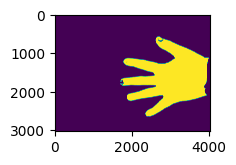

1


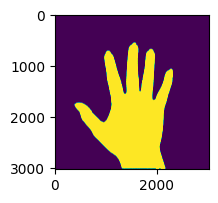

2


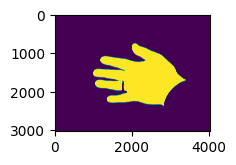

3


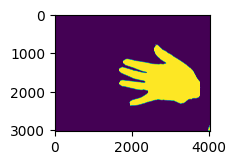

4


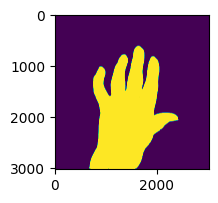

5


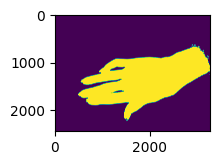

6


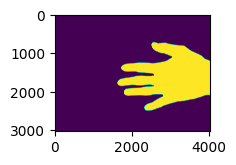

7


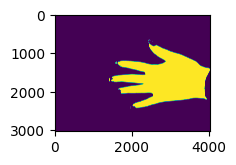

8


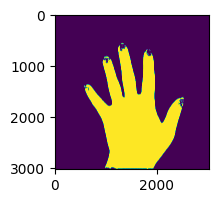

9


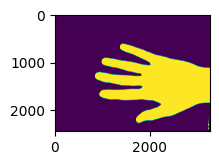

10


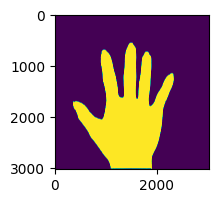

11


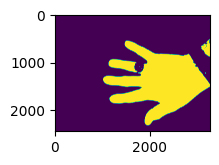

12


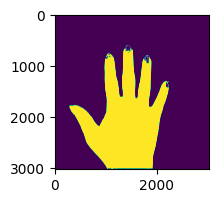

13


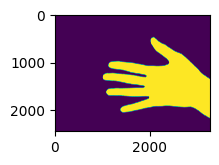

14


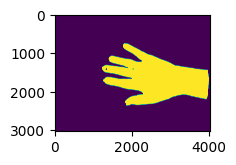

15


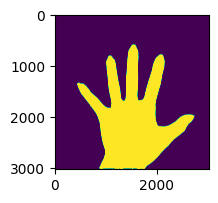

16


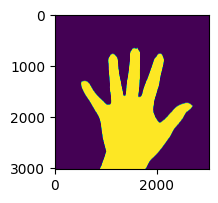

17


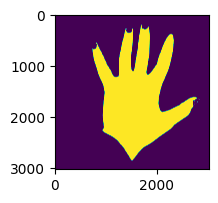

18


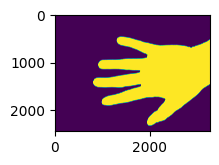

19


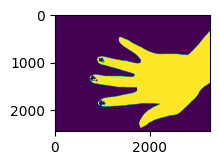

20


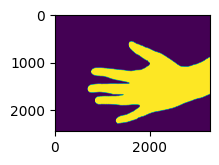

21


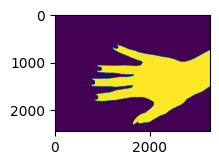

22


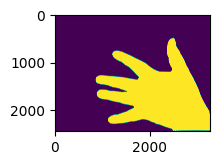

23


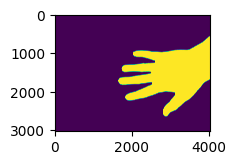

24


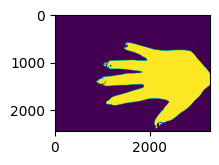

25


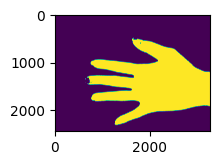

26


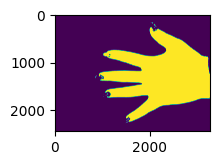

27


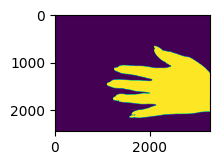

28


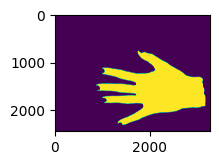

29


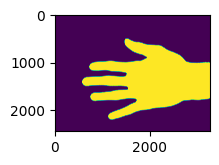

30


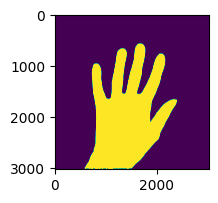

31


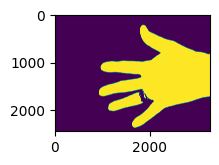

: 

In [ ]:
i = 0
for k in small_area:
    print(i)
    plt.figure(figsize=(2,2))
    plt.imshow(segmentations[k])
    plt.show()
    i += 1